# Binary Hate Speech Classifier Training (Logistic Regression)
This script trains a binary classifier to predict "Hate Speech" (1) vs "Not Hate" (0) using 
TF-IDF Vectorization and Logistic Regression.
It splits the dataset into 70% Training, 15% Validation, and 15% Testing, and exports 
the weights in a Softmax-compatible format for client-side JavaScript.


In [37]:
# 1. Imports
import pandas as pd
import numpy as np
import json
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


## 2. Load the Dataset


In [38]:
# Load data (change path if necessary)
try:
    # 1. Check local directory candidates
    balanced_path = os.path.join("..", "data", "balanced_data.csv")
    if not os.path.exists(balanced_path):
        balanced_path = os.path.join("..", "..", "data", "balanced_data.csv")
    if not os.path.exists(balanced_path) and os.path.exists("balanced_data.csv"):
        balanced_path = "balanced_data.csv"
        
    if os.path.exists(balanced_path):
        df = pd.read_csv(balanced_path)
        print(f"Dataset loaded successfully from local path {balanced_path}! Total records: {len(df)}")
    else:
        # 2. Fallback to GitHub raw URL for remote run (e.g. Colab)
        github_url = "https://raw.githubusercontent.com/M-Hasaam/hate-speech-detector/main/data/balanced_data.csv"
        print(f"Dataset not found locally. Fetching directly from GitHub: {github_url} ...")
        df = pd.read_csv(github_url)
        print(f"Dataset loaded successfully from GitHub! Total records: {len(df)}")
except Exception as e:
    print(f"Error: Could not load dataset. Details: {e}")


# Resolve output directory for models and plots
if "__file__" in locals() or "__file__" in globals():
    output_dir = os.path.dirname(os.path.abspath(__file__))
else:
    output_dir = "train" if os.path.exists("train") else "."

# Drop any rows with NaN tweets
df = df.dropna(subset=['tweet'])


Dataset not found locally. Fetching directly from GitHub: https://raw.githubusercontent.com/M-Hasaam/hate-speech-detector/main/data/balanced_data.csv ...
Dataset loaded successfully from GitHub! Total records: 8324


## 3. Analyze Class Balance
Class 0: Not Hate (Clean/Neutral)
Class 1: Hate Speech


In [39]:
class_counts = df['class'].value_counts()
print("Class distribution:")
for cls, count in class_counts.items():
    label = {0: "Not Hate", 1: "Hate Speech"}[cls]
    print(f"  {label} ({cls}): {count} ({count/len(df)*100:.2f}%)")


Class distribution:
  Not Hate (0): 4162 (50.00%)
  Hate Speech (1): 4162 (50.00%)


## 4. Feature Extraction (TF-IDF Vectorization)
Convert text to numerical TF-IDF vectors using 1-to-2 n-grams.
We limit features to top 12,000 words to match the extension capacity.


In [40]:
vectorizer = TfidfVectorizer(max_features=12000, ngram_range=(1, 2), stop_words='english', sublinear_tf=True)

X = vectorizer.fit_transform(df['tweet'])
y = df['class'].values

# Split into train and remaining temp pools (70% train, 30% temp)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Split temp pool in half (15% validation, 15% test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 5826, Validation size: 1249, Test size: 1249


## 5. Train the Model
We will use Logistic Regression. C=2.0 helps prevent overfitting.
We set class_weight='balanced' to handle any slight class imbalance.


In [41]:
model = LogisticRegression(class_weight='balanced', C=2.0, max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(C=2.0, class_weight='balanced', max_iter=1000)

## 6. Evaluate the Model
Evaluate on the validation set first, then verify on the test set.


In [42]:
print("\n=== Validation Set Evaluation ===")
y_val_pred = model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=["Not Hate", "Hate Speech"]))

print("\n=== Test Set Evaluation ===")
y_test_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=["Not Hate", "Hate Speech"]))

print("\n=== Confusion Matrix (Validation) ===")
print(confusion_matrix(y_val, y_val_pred))

print("\n=== Confusion Matrix (Test) ===")
print(confusion_matrix(y_test, y_test_pred))



=== Validation Set Evaluation ===
Validation Accuracy: 0.9367493995196157

Classification Report (Validation):
              precision    recall  f1-score   support

    Not Hate       0.91      0.97      0.94       624
 Hate Speech       0.97      0.90      0.93       625

    accuracy                           0.94      1249
   macro avg       0.94      0.94      0.94      1249
weighted avg       0.94      0.94      0.94      1249


=== Test Set Evaluation ===
Test Accuracy: 0.9439551641313051

Classification Report (Test):
              precision    recall  f1-score   support

    Not Hate       0.92      0.98      0.95       625
 Hate Speech       0.97      0.91      0.94       624

    accuracy                           0.94      1249
   macro avg       0.95      0.94      0.94      1249
weighted avg       0.95      0.94      0.94      1249


=== Confusion Matrix (Validation) ===
[[605  19]
 [ 60 565]]

=== Confusion Matrix (Test) ===
[[610  15]
 [ 55 569]]


## 6.1. Visualize Logistic Regression Model Coefficients & Sigmoid Probability Curve
We plot the top words that drive predictions and visualize the distribution of prediction confidence.



Top 15 words predicting 'Not Hate':
  trash: -5.4628
  bird: -5.2885
  charlie: -5.1865
  yankees: -4.9629
  yellow: -4.9610
  birds: -3.4527
  colored: -3.1994
  brownies: -3.1446
  monkey: -2.9809
  mock: -2.7081
  oreo: -2.5647
  yankee: -2.4896
  sole: -2.4108
  jihadi: -2.3129
  oreos: -2.0547

Top 15 words predicting 'Hate Speech':
  bitch: 17.3824
  bitches: 12.5792
  hoes: 10.0327
  pussy: 9.9614
  hoe: 8.2877
  shit: 5.9018
  ass: 5.8186
  fuck: 5.7257
  faggot: 5.6704
  fucking: 5.0826
  niggah: 4.8255
  nigga: 4.5637
  cunt: 4.0909
  nigger: 3.9324
  fag: 3.7394


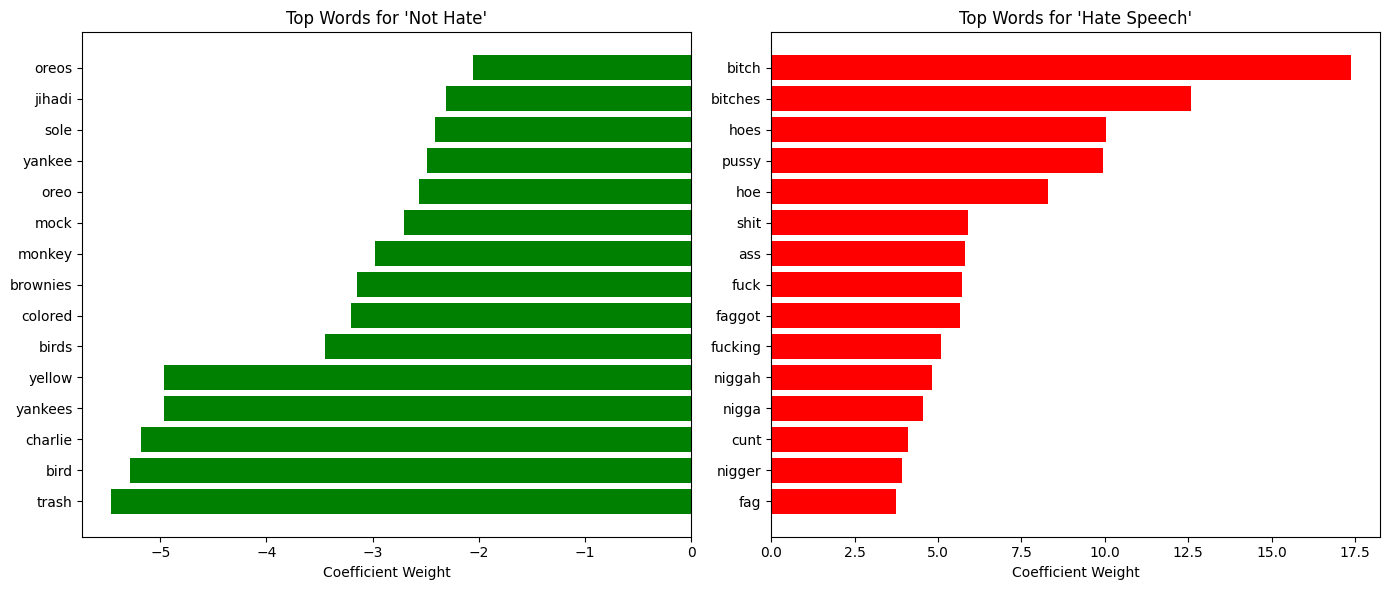

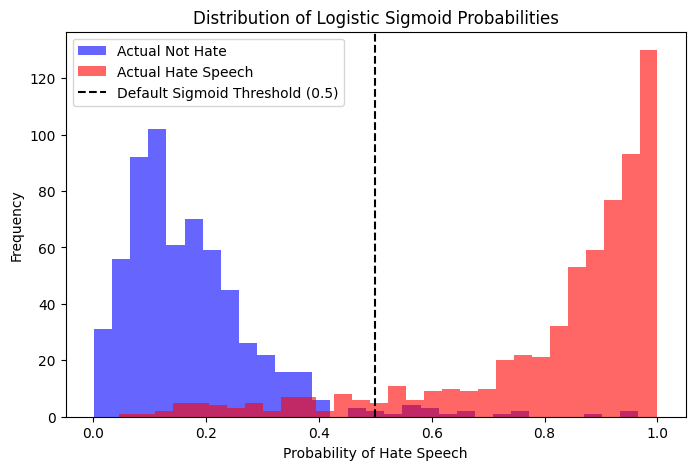

In [43]:
# Extract top words with highest and lowest coefficients
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = model.coef_[0]
sorted_coef_indices = np.argsort(coefs)

top_not_hate_words = feature_names[sorted_coef_indices[:15]]
top_not_hate_coefs = coefs[sorted_coef_indices[:15]]

top_hate_words = feature_names[sorted_coef_indices[-15:]]
top_hate_coefs = coefs[sorted_coef_indices[-15:]]

print("\nTop 15 words predicting 'Not Hate':")
for word, coef in zip(top_not_hate_words, top_not_hate_coefs):
    print(f"  {word}: {coef:.4f}")

print("\nTop 15 words predicting 'Hate Speech':")
for word, coef in zip(top_hate_words[::-1], top_hate_coefs[::-1]):
    print(f"  {word}: {coef:.4f}")

# Plotting the Logistic Regression Coefficients
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.barh(top_not_hate_words, top_not_hate_coefs, color='green')
plt.title("Top Words for 'Not Hate'")
plt.xlabel("Coefficient Weight")

plt.subplot(1, 2, 2)
plt.barh(top_hate_words, top_hate_coefs, color='red')
plt.title("Top Words for 'Hate Speech'")
plt.xlabel("Coefficient Weight")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "logistic_coefficients.png"))
plt.show()

# Plot Sigmoid Curve / Prediction Probabilities Distribution
y_val_probs = model.predict_proba(X_val)[:, 1] # Probability of Class 1 (Hate)
plt.figure(figsize=(8, 5))
plt.hist(y_val_probs[y_val == 0], bins=30, alpha=0.6, label='Actual Not Hate', color='blue')
plt.hist(y_val_probs[y_val == 1], bins=30, alpha=0.6, label='Actual Hate Speech', color='red')
plt.axvline(0.5, color='black', linestyle='--', label='Default Sigmoid Threshold (0.5)')
plt.title("Distribution of Logistic Sigmoid Probabilities")
plt.xlabel("Probability of Hate Speech")
plt.ylabel("Frequency")
plt.legend()
plt.savefig(os.path.join(output_dir, "logistic_probability_curve.png"))
plt.show()


## 7. Export Model to JSON for JavaScript Softmax Predictor
We map the 1D binary Logistic Regression weights into a 2D matrix 
representing 2 classes to maintain complete compatibility with predictor.js.


In [44]:
# Extract vocabulary mapping (word -> vector index) and cast values to native Python ints
vocabulary = {word: int(idx) for word, idx in vectorizer.vocabulary_.items()}

# Get IDF values
idf = vectorizer.idf_.tolist()

# Binary regression outputs coefficients of shape (1, n_features) and intercept of shape (1,)
coef_raw = model.coef_[0].tolist()
intercept_raw = float(model.intercept_[0])

# Map to 2 classes to support the JavaScript Softmax Predictor:
# Class 0 (Not Hate): Coefficients = all 0.0, Intercept = 0.0
# Class 1 (Hate Speech): Coefficients = actual model coefficients, Intercept = actual intercept
coefficients = [
    [0.0] * len(vocabulary),  # Class 0
    coef_raw                 # Class 1
]
intercept = [
    0.0,                     # Class 0
    intercept_raw            # Class 1
]

# Save everything into a single JSON model package
model_package = {
    "vocabulary": vocabulary,
    "idf": idf,
    "coefficients": coefficients,
    "intercept": intercept,
    "classes": [0, 1]
}

# Resolve file write destination
output_path = os.path.join(output_dir, "model_weights.json")
with open(output_path, "w") as f:
    json.dump(model_package, f)

print(f"\nModel successfully exported to {output_path}!")

# Create and display download link for the JSON model weights directly in the notebook output
try:
    from IPython.display import HTML, display
    import base64
    
    with open(output_path, 'r') as f:
        json_data = f.read()
    b64 = base64.b64encode(json_data.encode()).decode()
    html_link = f'''
    <div style="padding: 12px 20px; border: 2px solid #007acc; background-color: #f0f8ff; border-radius: 8px; margin-top: 15px; display: inline-block;">
        <a href="data:application/json;base64,{b64}" download="model_weights.json" style="font-size: 16px; color: #007acc; font-weight: bold; text-decoration: none;">
            📥 Click here to download model_weights.json
        </a>
    </div>
    '''
    display(HTML(html_link))
except Exception as e:
    print(f"Could not generate download link: {e}")




Model successfully exported to ./model_weights.json!


## 8. Download Outputs (Google Colab only)
Automatically download the exported model weights and plots to your local machine if running in a Colab environment.


In [45]:
try:
    from google.colab import files
    print("Colab environment detected. Triggering file downloads...")
    files.download(output_path)
    files.download("logistic_coefficients.png")
    files.download("logistic_probability_curve.png")
except ImportError:
    print("Not running in Google Colab. Files are saved locally.")



Colab environment detected. Triggering file downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>